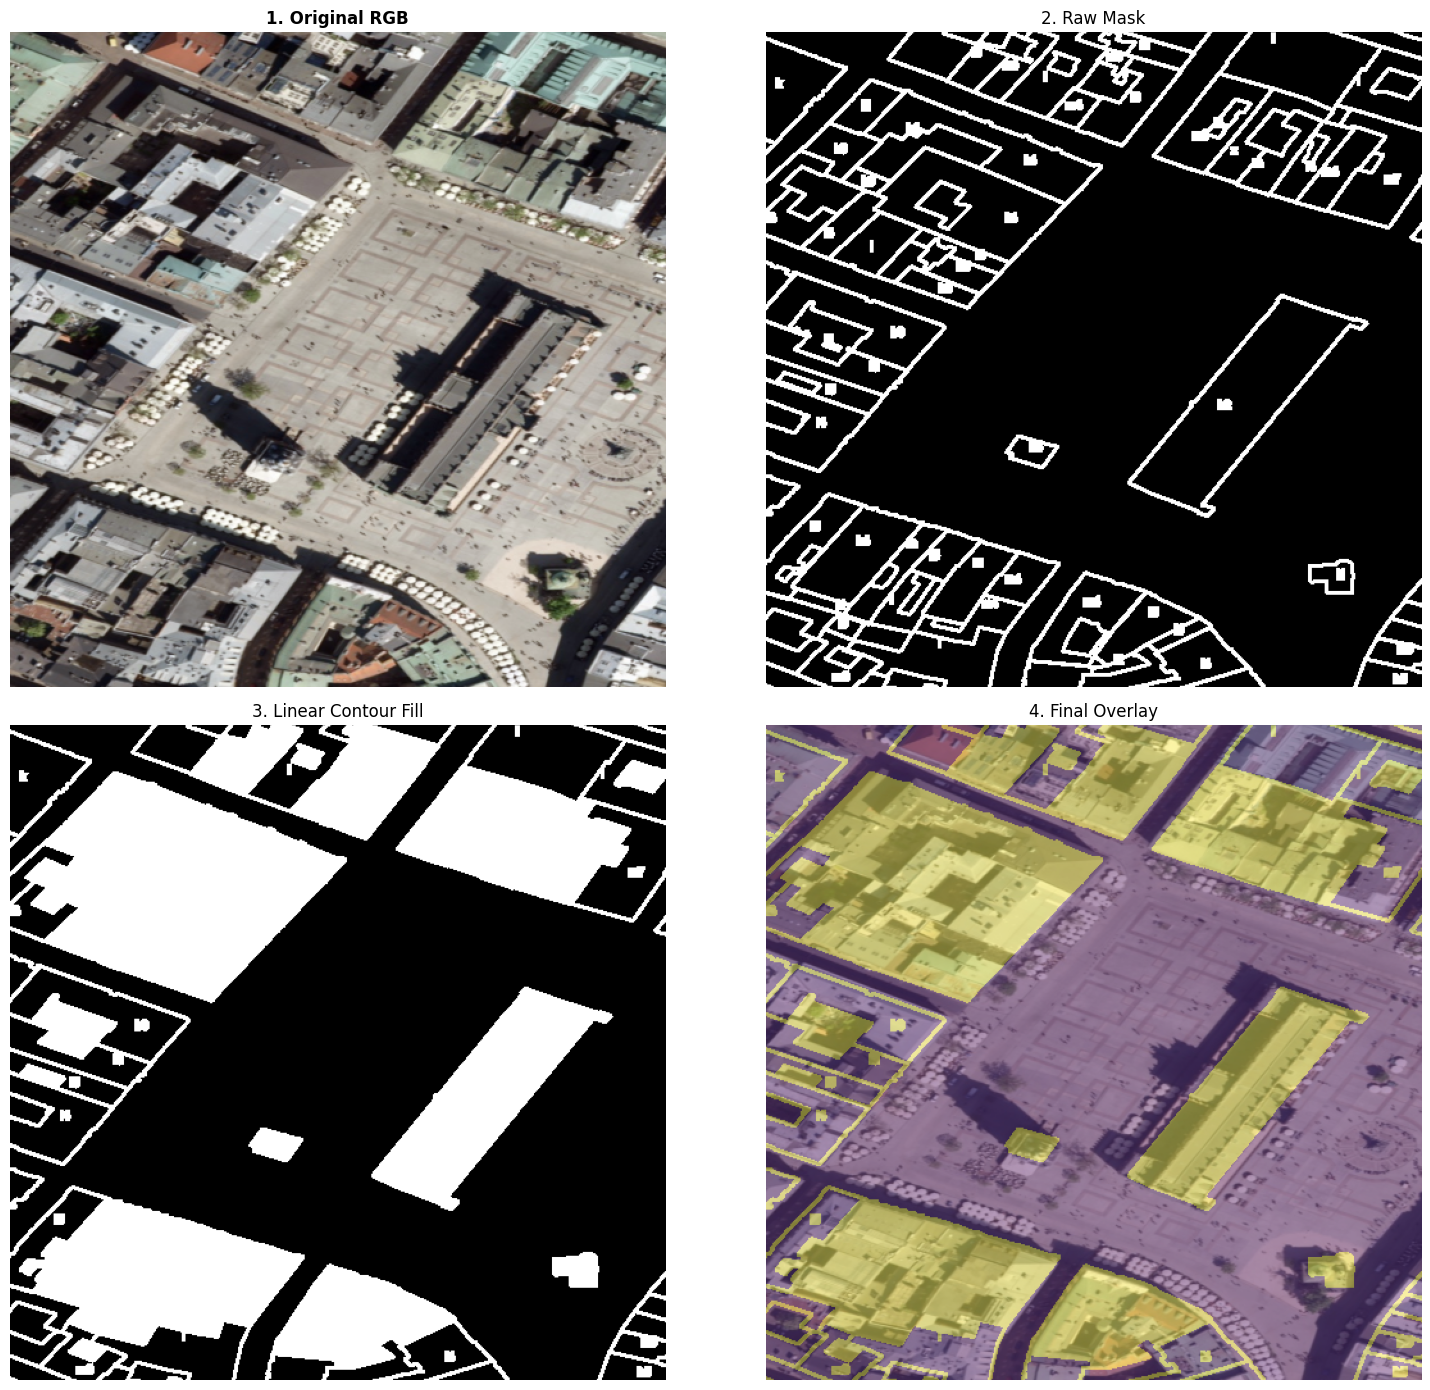


Done.


In [4]:
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import show
import numpy as np
import cv2

name = "krakow_center"
img_path = f"../data/raw/{name}_img.tif"
mask_path = f"../data/raw/{name}_mask.tif"
src_img = rasterio.open(img_path)
src_mask = rasterio.open(mask_path)

img_data = src_img.read()
raw_mask = src_mask.read(1)

mask_8bit = raw_mask.astype(np.uint8)
contours, _ = cv2.findContours(mask_8bit, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

processed_mask = np.zeros_like(mask_8bit)
cv2.drawContours(processed_mask, contours, -1, 255, thickness=-1)

fig, ax = plt.subplots(2, 2, figsize=(16, 14))

show(src_img, ax=ax[0, 0], title="1. Original RGB")

ax[0, 1].imshow(raw_mask, cmap='gray')
ax[0, 1].set_title("2. Raw Mask")

ax[1, 0].imshow(processed_mask, cmap='gray')
ax[1, 0].set_title("3. Linear Contour Fill")

ax[1, 1].imshow(np.moveaxis(img_data, 0, -1))
ax[1, 1].imshow(processed_mask, alpha=0.4)
ax[1, 1].set_title("4. Final Overlay")

for a in ax.flat: 
    a.axis('off')
    
plt.tight_layout()
plt.show()

src_img.close()
src_mask.close()

print("\nDone.")